<a href="https://colab.research.google.com/github/chandu01432/Upskill/blob/main/Encoder_Decoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Seq2Seq**

-- When we want input and output to be some kind of sequence and both of their length can differ.

In [ ]:
# input -- Give me an image of a banana and a tractor -- sequence -- text
# output -- image -- array of pixels -- sequence

In [ ]:
# text -- text  # Seq2Seq task
# text -- image # Multimodel Seq-2-Seq
# text -- video # Multimodel Seq-2-Seq

In [ ]:
# Deep learning models like RNN and LSTM can do some of seq2seq tasks but
# not very efficiently the output can  be very inaccurate.

1. Machine Translation
good afternoon -- bon apres midi

2. Chatbot conversation
normal conversation with gemini

3. Answering basic questions into 2-3 lines

4. Humanizer

5. Text summarization
we convert long paras into short summaries

Why RNN and LSTM aren't good for such tasks?
- lets see their shortcomings

## RNN -- Recurrent Neural Network

In [ ]:
# I love Gen __.
# RNN can fill the blank .

# I love GEN AI.

# But if you ask it to give a whole summary about this thing . generate a para of 150 words.

In [ ]:
# It fails because of vanishing and exploding gradients.

In [ ]:
# Vanishing gradient problem = gradients shrink too much,
# while Exploding gradient problem = gradients grow too much during backpropagation

## LSTM -- Long Short Term Memory

if we want to generate variable length output LSTM will struggle to do so as LSTM too cannot remember a lot of previous sequences

seq1--> seq2 --> seq3-->

# Encoder - Decoder

In [ ]:
# Two part architecture which can have RNNs, LSTMs, stack of LSTMs as well

In [ ]:
# Encoder -- reads the entire input sequence -- compresses it into a summary -- Context vector.

In [ ]:
# Decoder -- Takes the context vector and generates the output step by step.

https://intellipaatsoft-my.sharepoint.com/:o:/g/personal/divya_intellipaatsoft_onmicrosoft_com/IgAtEFDCyZdJTIaZK6hCdXD7AcKKszqaFwbNeOxLq3ekjlY

# HandsOn

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
data = [ ("i am happy","मैं खुश हूँ"),
         ("You are sad","आप दुखी हैं"),
         ("she is tired", "वह थक गया है"),
         ("we are hungry","हम भूखें है"),
         ("they are busy","वे व्यस्त हैं"),
         ("i am cold","मुझे ठंड लग रही है"),
         ("you are late","तुम देरी से आए हो"),
         ("she is happy", "वह खुश है"),
         ("we are ready","हम तैयार हैं")]

In [ ]:
data[0]

('i am happy', 'मैं खुश हूँ')

In [ ]:
data[0][0]

'i am happy'

In [ ]:
data[0][1]

'मैं खुश हूँ'

In [ ]:
eng_sen = []
hin_sen = []

for sen in data:
  eng_sen.append(sen[0])
  hin_sen.append(sen[1])


In [ ]:
eng_sen

['i am happy',
 'You are sad',
 'she is tired',
 'we are hungry',
 'they are busy',
 'i am cold',
 'you are late',
 'she is happy',
 'we are ready']

In [ ]:
hin_sen

['मैं खुश हूँ',
 'आप दुखी हैं',
 'वह थक गया है',
 'हम भूखें है',
 'वे व्यस्त हैं',
 'मुझे ठंड लग रही है',
 'तुम देरी से आए हो',
 'वह खुश है',
 'हम तैयार हैं']

## Add <\start> and <\end>

In [ ]:
hin_sen = ['<start>'+sen+"<end>" for sen in hin_sen]

In [ ]:
hin_sen

['<start>मैं खुश हूँ<end>',
 '<start>आप दुखी हैं<end>',
 '<start>वह थक गया है<end>',
 '<start>हम भूखें है<end>',
 '<start>वे व्यस्त हैं<end>',
 '<start>मुझे ठंड लग रही है<end>',
 '<start>तुम देरी से आए हो<end>',
 '<start>वह खुश है<end>',
 '<start>हम तैयार हैं<end>']

## Tokenisation

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
eng_tokenizer = Tokenizer()
hin_tokenizer = Tokenizer()

In [ ]:
eng_tokenizer.fit_on_texts(eng_sen)
hin_tokenizer.fit_on_texts(hin_sen)

In [ ]:
eng_seq = eng_tokenizer.texts_to_sequences(eng_sen)
hin_seq = hin_tokenizer.texts_to_sequences(hin_sen)

In [ ]:
eng_seq

[[2, 3, 4],
 [5, 1, 9],
 [6, 7, 10],
 [8, 1, 11],
 [12, 1, 13],
 [2, 3, 14],
 [5, 1, 15],
 [6, 7, 4],
 [8, 1, 16]]

In [ ]:
hin_seq

[[1, 8, 5, 9, 2],
 [1, 10, 11, 4, 2],
 [1, 6, 12, 13, 3, 2],
 [1, 7, 14, 3, 2],
 [1, 15, 16, 4, 2],
 [1, 17, 18, 19, 20, 3, 2],
 [1, 21, 22, 23, 24, 25, 2],
 [1, 6, 5, 3, 2],
 [1, 7, 26, 4, 2]]

In [ ]:
print(eng_tokenizer.word_counts)

OrderedDict({'i': 2, 'am': 2, 'happy': 2, 'you': 2, 'are': 5, 'sad': 1, 'she': 2, 'is': 2, 'tired': 1, 'we': 2, 'hungry': 1, 'they': 1, 'busy': 1, 'cold': 1, 'late': 1, 'ready': 1})


In [ ]:
print(eng_tokenizer.word_index)

{'are': 1, 'i': 2, 'am': 3, 'happy': 4, 'you': 5, 'she': 6, 'is': 7, 'we': 8, 'sad': 9, 'tired': 10, 'hungry': 11, 'they': 12, 'busy': 13, 'cold': 14, 'late': 15, 'ready': 16}


In [ ]:
print(hin_tokenizer.word_index)

{'start': 1, 'end': 2, 'है': 3, 'हैं': 4, 'खुश': 5, 'वह': 6, 'हम': 7, 'मैं': 8, 'हूँ': 9, 'आप': 10, 'दुखी': 11, 'थक': 12, 'गया': 13, 'भूखें': 14, 'वे': 15, 'व्यस्त': 16, 'मुझे': 17, 'ठंड': 18, 'लग': 19, 'रही': 20, 'तुम': 21, 'देरी': 22, 'से': 23, 'आए': 24, 'हो': 25, 'तैयार': 26}


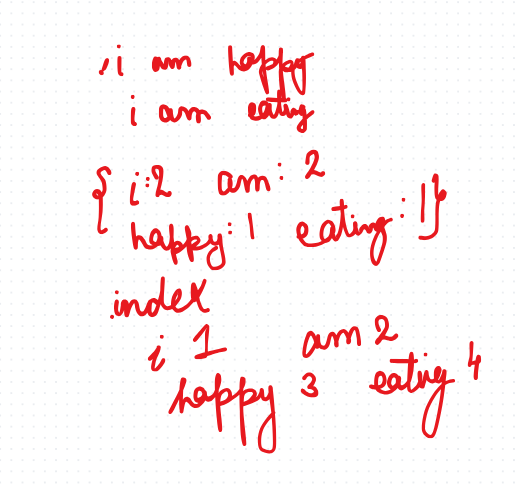

In [ ]:
eng_vocab_size = len(eng_tokenizer.word_index) + 1
hin_vocab_size = len(hin_tokenizer.word_index) + 1

In [ ]:
eng_vocab_size

17

In [ ]:
hin_vocab_size

27

## Padding

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
eng_padded = pad_sequences(eng_seq, padding = 'post')
hin_padded = pad_sequences(hin_seq, padding = 'post')

In [ ]:
eng_padded

array([[ 2,  3,  4],
       [ 5,  1,  9],
       [ 6,  7, 10],
       [ 8,  1, 11],
       [12,  1, 13],
       [ 2,  3, 14],
       [ 5,  1, 15],
       [ 6,  7,  4],
       [ 8,  1, 16]], dtype=int32)

In [ ]:
hin_seq

[[1, 8, 5, 9, 2],
 [1, 10, 11, 4, 2],
 [1, 6, 12, 13, 3, 2],
 [1, 7, 14, 3, 2],
 [1, 15, 16, 4, 2],
 [1, 17, 18, 19, 20, 3, 2],
 [1, 21, 22, 23, 24, 25, 2],
 [1, 6, 5, 3, 2],
 [1, 7, 26, 4, 2]]

In [ ]:
hin_padded

array([[ 1,  8,  5,  9,  2,  0,  0],
       [ 1, 10, 11,  4,  2,  0,  0],
       [ 1,  6, 12, 13,  3,  2,  0],
       [ 1,  7, 14,  3,  2,  0,  0],
       [ 1, 15, 16,  4,  2,  0,  0],
       [ 1, 17, 18, 19, 20,  3,  2],
       [ 1, 21, 22, 23, 24, 25,  2],
       [ 1,  6,  5,  3,  2,  0,  0],
       [ 1,  7, 26,  4,  2,  0,  0]], dtype=int32)

In [ ]:
max_eng_len = eng_padded.shape[1]
max_hin_len = hin_padded.shape[1]

In [ ]:
print(max_eng_len, max_hin_len)

3 7


In [ ]:
eng_padded1 = pad_sequences(eng_seq, maxlen= max_hin_len, padding = 'post')

In [ ]:
eng_padded1

array([[ 2,  3,  4,  0,  0,  0,  0],
       [ 5,  1,  9,  0,  0,  0,  0],
       [ 6,  7, 10,  0,  0,  0,  0],
       [ 8,  1, 11,  0,  0,  0,  0],
       [12,  1, 13,  0,  0,  0,  0],
       [ 2,  3, 14,  0,  0,  0,  0],
       [ 5,  1, 15,  0,  0,  0,  0],
       [ 6,  7,  4,  0,  0,  0,  0],
       [ 8,  1, 16,  0,  0,  0,  0]], dtype=int32)

In [ ]:
max_eng_len1 = eng_padded1.shape[1]

In [ ]:
max_eng_len1

7

#RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [ ]:
model = Sequential()

model.add(Embedding(input_dim = eng_vocab_size, output_dim = 64))

model.add(SimpleRNN(64, return_sequences = True))

model.add(Dense(hin_vocab_size, activation='softmax'))

model.compile(optimizer = 'adam',
              loss ='sparse_categorical_crossentropy',
              metrics =['accuracy'])

model.build(input_shape=(None,max_eng_len1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 7, 64)          │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 7, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7, 27)          │         1,755 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,099 (43.36 KB)

 Trainable params: 11,099 (43.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(eng_padded1, hin_padded,
          epochs = 50,
          batch_size = 2)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1746 - loss: 3.2441  
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3016 - loss: 3.1009
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4127 - loss: 2.9117
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4444 - loss: 2.6729
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4444 - loss: 2.4783
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4762 - loss: 2.3641
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4762 - loss: 2.2966
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4921 - loss: 2.2320
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5079 - loss: 2.1556
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5873 - loss: 2.0890
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6032 - loss: 2.0262
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6508 - loss: 1.9462

In [ ]:
pred = model.predict(eng_padded1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


In [ ]:
pred.shape

(9, 7, 27)

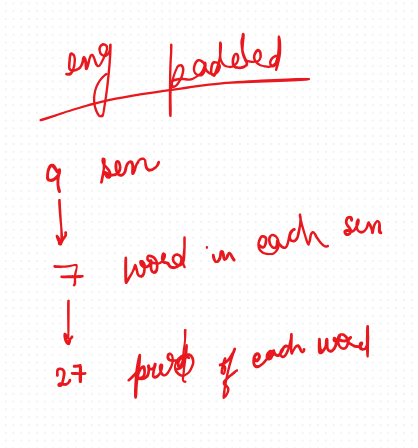

In [ ]:
pred_seq = np.argmax(pred, axis = -1)
print(pred_seq)

[[ 1 17  5  9  2  0  0]
 [ 1 21 11  4  2  0  0]
 [ 1  6 12 13  3  2  0]
 [ 1  7 14  3  2  0  0]
 [ 1 15 16  4  2  0  0]
 [ 1 17 18 19 20  3  2]
 [ 1 21 22 23 24 25  2]
 [ 1  6  5  3  2  0  0]
 [ 1  7 26  4  2  0  0]]


In [ ]:
for seq in pred_seq:
  sentence =[]
  for idx in seq:
    if idx != 0:
      word = hin_tokenizer.index_word.get(idx," ")
      sentence.append(word)
  print(" ".join(sentence))

start मुझे खुश हूँ end
start तुम दुखी हैं end
start वह थक गया है end
start हम भूखें है end
start वे व्यस्त हैं end
start मुझे ठंड लग रही है end
start तुम देरी से आए हो end
start वह खुश है end
start हम तैयार हैं end


# Encoder - Decoder

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense

eng_vocab_size = len(eng_tokenizer.word_index) + 1
hin_vocab_size = len(hin_tokenizer.word_index) + 1

embedding_dim = 64
lstm_units = 128

# encoder
encoder_inputs = Input(shape=(None,), name="encoder_input")
enc_emb = Embedding(eng_vocab_size, embedding_dim, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(lstm_units, return_state=True)
_, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c] # context vector

# decoder
decoder_inputs = Input(shape=(None,), name="decoder_input")
dec_emb_layer = Embedding(hin_vocab_size, embedding_dim, mask_zero=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(hin_vocab_size, activation='softmax')
output = decoder_dense(decoder_outputs)

model = Model([encoder_inputs, decoder_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

print(model.summary())


decoder_target_data = np.zeros_like(hin_padded)
decoder_target_data[:, :-1] = hin_padded[:, 1:]


model.fit([eng_padded, hin_padded],
          np.expand_dims(decoder_target_data, -1),
          batch_size=2,
          epochs=50)

# inference models (for translation/prediction)

# Encoder model (output the states) # context vector
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder model (takes tokens + initial states, outputs next token)
decoder_state_input_h = Input(shape=(lstm_units,))
decoder_state_input_c = Input(shape=(lstm_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb2 = dec_emb_layer(decoder_inputs)
decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    dec_emb2, initial_state=decoder_states_inputs
)
decoder_states2 = [state_h2, state_c2]
decoder_outputs2 = decoder_dense(decoder_outputs2)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

# Function to translate English -> Hindi

reverse_hin_index = {v: k for k, v in hin_tokenizer.word_index.items()}

def translate_sentence(input_seq):
    states_value = encoder_model.predict(input_seq)

    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = hin_tokenizer.word_index['start']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value)

        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = reverse_hin_index.get(sampled_token_index, '')

        if sampled_word == 'end' or len(decoded_sentence.split()) > 10:
            stop_condition = True
        else:
            decoded_sentence += ' ' + sampled_word

        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    return decoded_sentence.strip()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, None, 64)  │      1,088 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None)      │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 64)  │      1,728 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     98,816 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ not_equal[0][0]   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, None,     │     98,816 │ embedding_2[0][0… │
│                     │ 128), (None,      │            │ lstm[0][1],       │
│                     │ 128), (None,      │            │ lstm[0][2]        │
│                     │ 128)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 27)  │      3,483 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 203,931 (796.61 KB)

 Trainable params: 203,931 (796.61 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 3.2897
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.2563
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.2064
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 3.1011
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.8391
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.5414
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.5438
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 2.4360
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.3866
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.3388
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2654
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.2182
Epoch 13/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.1669
Epoch 14/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.0981
Epoch 15/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.0275
Epoch 16/50
5/5 ━━━━━━━━━━━━━

In [ ]:
translated = translate_sentence(eng_padded[0:1])
print("English input:", eng_sen[0:1])
print("Predicted Hindi:", translated)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
English input: ['i am happy']
Predicted Hindi: मैं खुश हूँ


In [ ]:
translated = translate_sentence(eng_padded[1:2])
print("English input:", eng_sen[1:2])
print("Predicted Hindi:", translated)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
English input: ['You are sad']
Predicted Hindi: आप दुखी हैं


In [ ]:
translated = translate_sentence(eng_padded[2:3])
print("English input:", eng_sen[2:3])
print("Predicted Hindi:", translated)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
English input: ['she is tired']
Predicted Hindi: वह थक गया है
